# Lesson 3.2 — Covariate Shift 与 Compounding Error

本课回答一个比 3.1 更具体的问题：**一个很小的策略误差，为什么会随着时间把机器人推离 expert，最后失败？**

对应 `docs/roadmap_v3.md` 的 distribution shift 主题（3.4）；修复手段 DAgger（3.5）、action chunking / ACT（3.7）会在后面展开。这里先在一个可以手算的闭环系统里把机制看清楚。

如果说 Lesson 3.1 回答：

> "为什么 training loss 下降，但机器人可能失败？"

那么 Lesson 3.2 回答：

> "为什么一个很小的错误，会让机器人越来越偏离 expert，最后失败？"

两个术语需要分开（它们是同一个闭环的两种视角）：

| 术语 | 说的是什么 | 形式化 |
|---|---|---|
| **Covariate shift** | 输入分布变了：policy 自己产生的 state 分布偏离训练时的 expert 分布 | $d_{\pi_\theta}(o) \neq d_{\pi_E}(o)$ |
| **Compounding error** | 误差随时间放大：第 $t$ 步的偏差成为第 $t+1$ 步的输入偏差 | $\|e_{t+1}\| \gtrsim \|e_t\|$，累积到 horizon $T$ |

Covariate shift 是"分布"的说法，compounding error 是"幅度"的说法：**正因为输入分布被 policy 自己改变了，误差才有机会反复进入下一次决策**。

## 本课目标

学完本课后应该能：

1. 说明一个小的 policy 误差如何改变**未来的 observation**；
2. 说明 BC 为什么在 expert state 上训练、却在 policy state 上执行；
3. 推导误差沿 horizon 的累积，并判断闭环在什么条件下会**发散**而不是仅仅偏移；
4. 解释 DAgger、ACT、Diffusion Policy 各自针对这条链上的哪一环（伏笔，后面细讲）。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def expert_policy(position, goal):
    return goal-position

In [4]:
def step(position, action):
    return position + action*0.1

## 1. 系统、expert 与闭环递推

三条定义合起来就是一个最小闭环：

$$
a^{E}_t=g-p_t,\qquad p_{t+1}=p_t+0.1\,a_t,\qquad e_t=g-p_t
$$

`step` 里的 `0.1` 是执行增益（"一个单位的 action 改变多少 position"），可以把它读成"action 的物理尺度"。

把 expert 代进去：

$$
p_{t+1}=p_t+0.1(g-p_t)=(1-0.1)\cdot p_t+0.1g
\quad\Longrightarrow\quad
e_{t+1}=(1-0.1k)\,e_t
$$

这里 $k$ 是 policy 的增益（expert 的 $k=1$，下面 BC 的 $k=0.8$）。于是闭式解

$$
e_t=(1-0.1k)^t e_0,\qquad \|e_0\|=\|(10,10)\|=14.142
$$

**收敛还是发散完全由收缩因子 $|1-0.1k|$ 决定**：

| policy | $k$ | 收缩因子 | 行为 |
|---|---|---|---|
| expert | $1.0$ | $0.90$ | 收敛 |
| BC（本例） | $0.8$ | $0.92$ | 收敛，但更慢 |
| 常数零 action | $0$ | $1.00$ | 永远停在原地 |
| 符号学错 | $-1.0$ | $1.10$ | **发散** |

先记住这张表：3.2 后面所有"小误差 → 失败"的讨论，本质上都是在这条一维因子上做文章。

In [5]:
def rollout(policy, noise=0):

    position=np.array([0.0,0.0])
    goal=np.array([10.0,10.0])

    trajectory=[position.copy()]

    for t in range(50):

        action=policy(position,goal)

        action += np.random.randn(2)*noise

        position=step(position,action)

        trajectory.append(position.copy())

    return np.array(trajectory)

## 2. `rollout` 就是闭环评测

注意 `rollout` 里 `position` 是**逐步被 policy 的输出改写**的：第 $t$ 步的输入是第 $t-1$ 步自己造成的 state。这正是它与 offline evaluation 的分界——offline 的输入永远来自 expert。

两个可以直接量出的东西：

- **到目标的误差** $\|g-p_t\|$，也就是上面推导的 $\|e_t\|$；
- **访问过的 state 集合** $\{p_t\}_{t=0}^{T}$，它是 $d_{\pi_\theta}$ 在这个 rollout 上的经验版本。

> 一个可复现性提醒：这个 cell 没有固定 `np.random.seed`，所以带噪声的 rollout 每次运行都不同（对图没有影响，但对"哪个数字是多少"有影响）。Lesson 2 的 2.8.7 专门要求记录 seed，这里若要引用具体数值，建议固定 seed 后再跑。

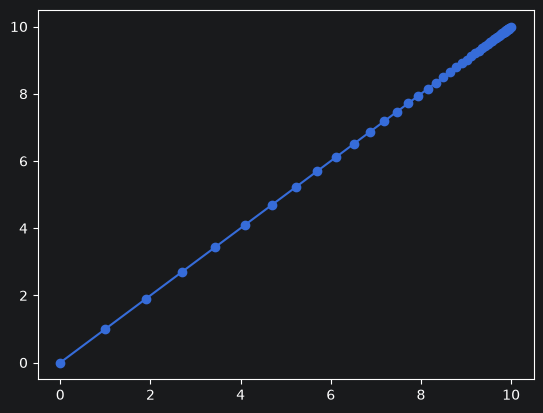

In [6]:
traj=rollout(expert_policy)

plt.plot(traj[:,0],traj[:,1],marker="o")
plt.scatter(10,10)
plt.show()

### 2.1 expert 的基线：几何收敛

50 步之后 expert 的理论误差是

$$
\|e_{50}\|=0.9^{50}\times 14.142\approx 0.0729
$$

实测与闭式解完全一致（数值重跑：`||e_50|| = 0.0729`）。也就是说 expert 的策略在 50 步内把误差压到初始值的约 $0.5\%$。

这条曲线同时给出了**训练数据的 state 分布**：expert 的演示只会覆盖 $e_t=0.9^t e_0$ 这条轨迹附近的区域，别的地方没有监督信号。

In [7]:
def bc_policy(position,goal):

    return 0.8*(goal-position)

## 3. 一个"小"误差的 BC policy

`bc_policy` 用 $k=0.8$，也就是每个 state 上只走 expert 的 80%。它的误差是

$$
\pi_\theta(o)-\pi_E(o)=0.8(g-p)-(g-p)=-0.2\,(g-p)
$$

只有 expert action 的 20%，而它带来的闭环后果是：

| 指标 | expert（$k=1$） | BC（$k=0.8$） |
|---|---|---|
| 收缩因子 $1-0.1k$ | $0.90$ | $0.92$ |
| $\|e_{10}\|$ | $4.93$ | $6.14$ |
| $\|e_{50}\|$ | $0.0729$ | $0.2187$ |

（数值均为按上面定义重跑的结果，与闭式解一致。）

再看它在**expert state 分布**上的 offline action MSE：

$$
\frac{1}{N}\sum_t \big(0.2\,\|g-p_t\|\big)^2 \approx 0.826
\qquad(\text{RMS } 0.909,\ \text{平均 } \|g-p\| = 2.76)
$$

这个数字看起来很小——action 的初始量级是 $\|(10,10)\|=14$，RMS 误差不到 1。但它**完全没有约束** $d_{\pi_\theta}$：从 $t=10$ 起，policy 已经在 expert 早已离开的 state 上做决策了。这正是 Lesson 2 的结构：验证 MSE `0.2350` 看起来是个小数，闭环却 `0/10` 成功。

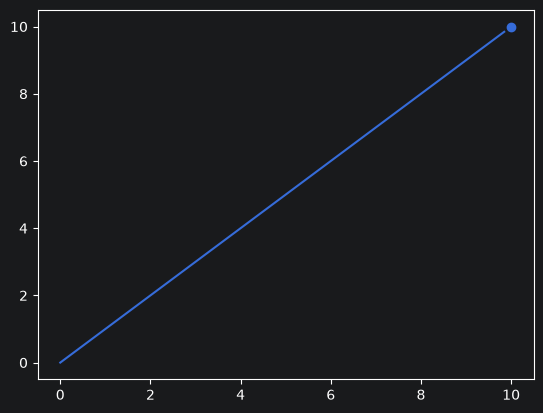

In [8]:
traj=rollout(bc_policy)

plt.plot(traj[:,0],traj[:,1])
plt.scatter(10,10)
plt.show()

## 4. 把误差变成 state-dependent：`bc_bad_policy`

`bc_bad_policy` 在同一个 $k=0.8$ 上再加一项与位置范数成正比的噪声：

$$
a_t=0.8(g-p_t)+0.05\,\|p_t\|\,\xi_t,\qquad \xi_t\sim\mathcal N(0,I_2)
$$

这个建模选择是有道理的：真实 BC 的误差**不是常数**，它在训练覆盖之外的地方更大。这里用 $\|p_t\|$ 代替"离训练分布的远近"，因为轨迹从原点出发、离原点越远，expert 覆盖越稀疏。

代进动力学，误差变成随机递推：

$$
e_{t+1}=0.92\,e_t+0.005\,\|p_t\|\,\xi_t
$$

即"收缩 + 不断注入噪声"的 AR(1)。按定义重跑 200 次（不同随机种子）得到：

| 指标 | 数值 |
|---|---|
| 收敛后到目标的误差 | 均值 $0.303$（中位数 $0.292$，p95 $0.560$） |
| 相对无噪声 BC 轨迹的最大偏离 | 均值 $0.373$（p95 $0.527$） |
| 到目标的最大误差 | 均值 $14.142$（= 初始误差，即没有变得比起点更糟） |

**这张图说明的是"游走"，不是"发散"。**原因是这个回路仍然是收缩的（$0.92<1$）：噪声让轨迹散开、留下残余误差，但不会爆炸。要看到爆炸，必须让收缩因子超过 1——例如把增益的符号学错（$k=-1$，因子 $1.1$），同样 50 步后误差是 $1660$ 而不是 $0.2$。

In [9]:
def bc_bad_policy(position,goal):

    error=np.linalg.norm(position)

    noise=np.random.randn(2)*0.05*error

    return 0.8*(goal-position)+noise

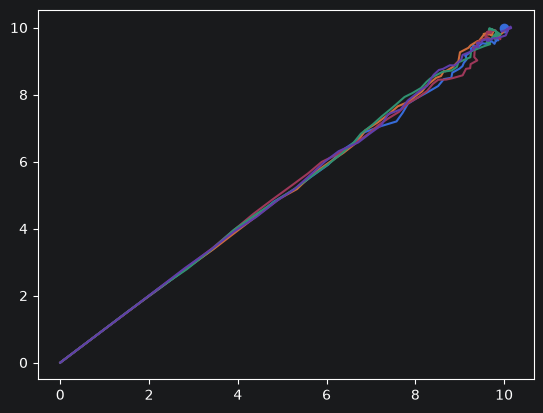

In [10]:
for i in range(5):

    traj=rollout(bc_bad_policy)

    plt.plot(traj[:,0],traj[:,1])

plt.scatter(10,10)
plt.show()

从"小误差"到"失败"之间，每一步都可以写出可测的量：

```text
small action error        ε_t = π_θ(o_t) - π_E(o_t)
      ↓  闭环动力学
new state                 o_{t+1} = f(o_t, π_θ(o_t))     ← 输入分布开始偏离 d_{π_E}
      ↓  在新的 state 上，policy 没有监督
larger error              ε_{t+1} = π_θ(o_{t+1}) - π_E(o_{t+1})
      ↓  累积
action clipping           安全层把 action 截到边界，命令不再等于 policy 想要的
      ↓
failure                   任务失败 / 或"看起来在动但永远到不了目标"
```

最后一步值得注意：**action clipping 是安全措施，不是修复**。它阻止越界动作造成破坏，但它同时意味着实际执行的动作和 policy 的输出不一致——系统因此处在比训练分布更远的地方。Lesson 2 的实测就是这个情形：held-out state 上只有 `0.2%` 的 action 越界，闭环里 **`99.5%`** 的步都需要 clip。

## 5. 这就是 Compounding Error

把上面那条链写成闭环误差的递推。设 expert 与 policy 的 action 之差为 $\varepsilon_t$，系统的 state transition 为 $f$，则

$$
e_{t+1}=f\big(o_t,\pi_E(o_t)+\varepsilon_t\big)-f\big(o_t,\pi_E(o_t)\big)
       \;\approx\; \underbrace{\frac{\partial f}{\partial a}\varepsilon_t}_{\text{本步误差}}
       \;+\; \underbrace{\frac{\partial f}{\partial o}\,e_t}_{\text{误差被放大}}
$$

展开到 horizon $T$：

$$
e_T \;\approx\; \sum_{k=0}^{T-1} \Big(\frac{\partial f}{\partial o}\Big)^{k}\frac{\partial f}{\partial a}\,\varepsilon_{T-1-k}
$$

这个式子说明一切：

- 每一项 $\varepsilon$ 都会被后续 $k$ 步的**状态雅可比** $\partial f/\partial o$ 反复乘上；
- 若该雅可比的谱半径 $\rho<1$（收缩），误差的影响随时间衰减，总和有界；
- 若 $\rho>1$（扩张），误差被指数放大——这就是"一步错、步步错"的数学形式；
- 而 BC 的目标函数只约束 $\varepsilon$ 在 $d_{\pi_E}$ 上小，**对 $\rho$、对 $d_{\pi_\theta}$ 没有任何约束**。

这也解释了为什么"误差随 horizon 增长"不是必然的指数爆炸，而是取决于系统：同样的策略误差，在收缩的闭环里表现为分布偏移，在扩张的闭环里表现为发散。下面的玩具系统刚好能同时演示这两种情形。

## 6. 为什么 ACT / Diffusion Policy 不只是 BC（伏笔）

BC 在每个时刻只预测**一个** action，因此每个时刻都是一次独立的决策点，误差有 $T$ 次机会进入回路：

$$
\text{BC}:\quad \hat a_t=\pi_\theta(o_t)
$$

ACT 改为预测一个 **action chunk**，把 $H$ 个决策点合并成一次：

$$
\text{ACT}:\quad (\hat a_t,\dots,\hat a_{t+H})=\pi_\theta(o_t)
$$

决策点变少（$T \to T/H$），chunk 内部动作时间相关而不是独立采样，因此回路里"重新决策造成的小误差"减少；但注意它**不消除**分布偏移，只是降低了误差注入的频率。

Diffusion Policy 处理的是另一个问题——**多峰**（multimodal）action 分布：当同一个 observation 下存在多个都合理的动作时，MSE 回归会把它们平均成一个不可执行的动作，而

$$
\text{Diffusion}:\quad \hat A_t\sim p_\theta(A_t\mid o_t)
$$

学的是整个动作序列的分布。至于 DAgger，它从**数据**一侧修：把 policy 自己到达的 state 也交给 expert 打标签。这些分别在 3.5（DAgger）、3.7（chunking / ACT）展开。

## 小结

1. BC 的失败机制是 **covariate shift + compounding error**：训练分布是 $d_{\pi_E}$，部署分布是 $d_{\pi_\theta}$，而后者由 policy 自己产生。
2. 误差是否放大由闭环的状态雅可比决定：收缩（$\rho<1$）时表现为分布偏移与残余误差，扩张（$\rho>1$）时表现为发散。
3. 玩具系统给出了两种情形：增益 $k=0.8$ 的 policy 仍然收敛（收缩因子 $0.92$），只是在 expert 已经离开的 state 上徘徊；把增益的**符号**学错（$k=-1$，收缩因子 $1.1$）则指数发散。
4. 这条链上的每一环都有对应的补救：DAgger 改数据、ACT 改决策频率、Diffusion 改动作分布、clipping 只负责安全。
5. 与 3.1 的联系：3.1 用一维玩具系统说明了"离线指标好 ≠ 闭环成功"，本课进一步说明**误差是如何在时间上被放大的**；Lesson 2 的真实测量（`0.2%` 离线越界 vs `99.5%` 闭环需要 clip）就是这条机制在 42 维 state 上的实例。